# Malware Detection from Network Flow Features

This notebook reproduces and extends the malware detection benchmark from the
pcapML / nPrint suite. The goal is to detect malicious network flows using
only flow-level statistics, without inspecting packet payloads.

In [15]:
# Install required packages not available by default
%pip install xgboost lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


In [16]:
# imports
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import xgboost as xgb
import lightgbm as lgb

### Data loading

The dataset is stored as a ZIP file inside the `data/` directory to keep the
repository lightweight. The following cell automatically unzips the dataset
(if needed) and loads the CSV file. No manual path changes are required.

In [17]:
import zipfile
import os
import pandas as pd

BASE_DIR = os.getcwd()

zip_path = os.path.join(
    BASE_DIR, "data", "traffic_flow_features_binary_custom.zip"
)

extract_dir = os.path.join(BASE_DIR, "traffic_data")

if not os.path.exists(extract_dir):
    print("Unzipping dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print("Dataset already unzipped.")

csv_path = os.path.join(
    extract_dir, "traffic_flow_features_binary_custom.csv"
)

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Dataset already unzipped.
Shape: (498446, 12)


,pkt_count,bytes_sum,pkt_size_mean,pkt_size_median,pkt_size_min,pkt_size_max,pkt_size_std,flow_duration,iat_mean,iat_std,iat_max,label
0,4.0,868.0,217.0,217.0,217.0,217.0,0.0,1.288497e+10,4.294991e+09,23715.960744,4.295024e+09,1
1,4.0,864.0,216.0,216.0,216.0,216.0,0.0,1.288490e+10,4.294968e+09,5589.445470,4.294974e+09,1
2,2.0,128.0,64.0,64.0,64.0,64.0,0.0,4.095170e+05,4.095170e+05,0.000000,4.095170e+05,1
3,4.0,868.0,217.0,217.0,217.0,217.0,0.0,1.288492e+10,4.294974e+09,8600.843021,4.294986e+09,1
4,2.0,136.0,68.0,68.0,68.0,68.0,0.0,4.294376e+09,4.294376e+09,0.000000,4.294376e+09,1


## Label Construction

Each flow is assigned a **binary label**:

- `1`: malware
- `0`: benign

The label is derived from metadata embedded in the original pcap file.
If the metadata string contains the keyword `"malware"`, the flow is labeled
as malicious. Otherwise, it is labeled as benign.

This binary formulation is used consistently across both supervised and
unsupervised experiments.

In [18]:
# class balance
df["label"].value_counts()

label
1    369325
0    129121
Name: count, dtype: int64

## Feature Engineering

Rather than operating on raw packets, each network flow is summarized using
flow-level statistics. These features capture:

- Traffic volume
- Packet size distribution
- Timing irregularities

This approach is realistic for modern encrypted traffic, where payload
inspection is not feasible.

### Model training and evaluation

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [20]:
# helper functions for evaluation

def print_metrics(y_true, y_pred, y_score, name="model"):
    acc  = accuracy_score(y_true, y_pred)
    bal  = balanced_accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_score)

    print(f"\n===== {name} =====")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Balanced Accuracy : {bal:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print(f"ROC AUC           : {auc:.4f}")


def plot_confusion(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
    fig, ax = plt.subplots()
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc(y_true, y_score, title="ROC curve"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc  = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Unsupervised Learning: One-Class SVM

Before using labels, we evaluate whether malware traffic can be detected
as anomalies using an unsupervised approach.

The One-Class SVM (OCSVM) is trained **only on benign flows**, under the
assumption that benign traffic dominates normal network operation.
Malware flows are expected to deviate from this learned distribution.

### Why OCSVM?

- Models real-world deployment scenarios with limited labels
- Does not require malware samples during training
- Serves as a baseline for anomaly detection

In [21]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report

X_train_benign = X_train[y_train == 0]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_benign)
X_test_sc  = scaler.transform(X_test)

ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.1,   
    gamma="scale",
)
ocsvm.fit(X_train_sc)

y_pred_oc = ocsvm.predict(X_test_sc) 
y_pred_label = (y_pred_oc == -1).astype(int)


cm = confusion_matrix(y_test, y_pred_label)
bal_acc = balanced_accuracy_score(y_test, y_pred_label)
print("Confusion matrix:\n", cm)
print("Balanced accuracy:", bal_acc)

print("\nClassification report:\n", classification_report(y_test, y_pred_label, digits=4))

Confusion matrix:
 [[34835  3901]
 [73453 37345]]
Balanced accuracy: 0.6181737340751889

Classification report:
               precision    recall  f1-score   support

           0     0.3217    0.8993    0.4739     38736
           1     0.9054    0.3371    0.4912    110798

    accuracy                         0.4827    149534
   macro avg     0.6136    0.6182    0.4826    149534
weighted avg     0.7542    0.4827    0.4867    149534



## Supervised Learning

We now train supervised classifiers using the same flow-level features.
Unlike the unsupervised baseline, these models directly learn the boundary
between benign and malicious traffic.

All models are evaluated on a held-out test set using:
- Accuracy
- Balanced Accuracy
- F1-score
- ROC AUC

### Logistic Regression (Baseline)

Logistic Regression serves as a linear baseline model.
It helps assess whether the classes are linearly separable in the
engineered feature space.


===== LogisticRegression =====
Accuracy          : 0.6145
Balanced Accuracy : 0.4667
F1-score          : 0.7483
ROC AUC           : 0.4435


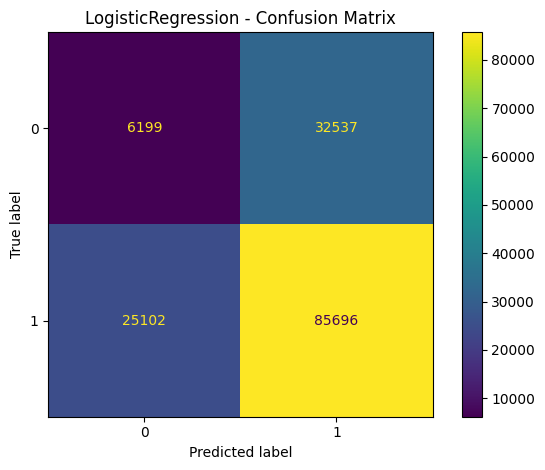

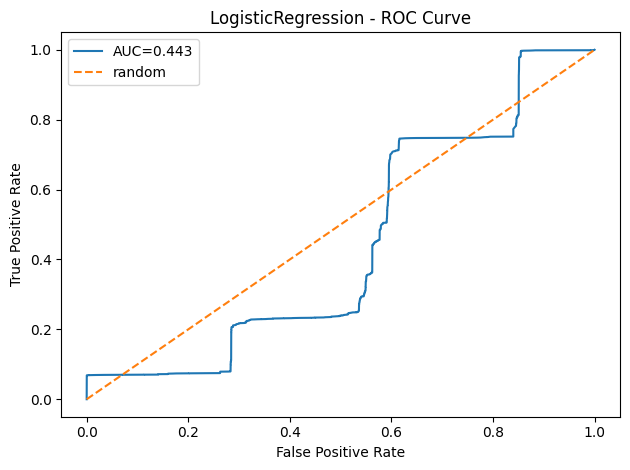

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    n_jobs=-1,
)

lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test)
y_score_lr = lr.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_lr, y_score_lr, name="LogisticRegression")
plot_confusion(y_test, y_pred_lr, title="LogisticRegression - Confusion Matrix")
plot_roc(y_test, y_score_lr, title="LogisticRegression - ROC Curve")

**Observation:**  
Performance is limited, suggesting that the relationship between features
and labels is non-linear.

### Random Forest

Random Forest is a non-linear ensemble model that captures complex
interactions between features. It is fast to train and robust to
feature scaling.


===== RandomForest =====
Accuracy          : 0.9982
Balanced Accuracy : 0.9978
F1-score          : 0.9988
ROC AUC           : 0.9999


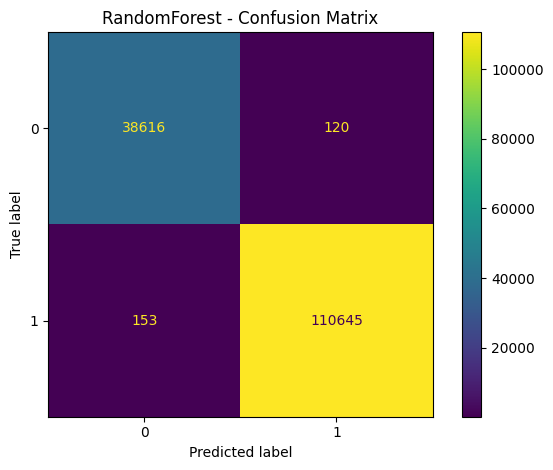

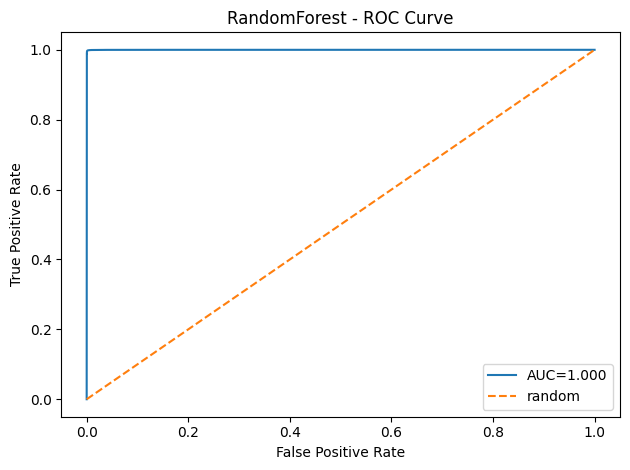

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_rf, y_score_rf, name="RandomForest")
plot_confusion(y_test, y_pred_rf, title="RandomForest - Confusion Matrix")
plot_roc(y_test, y_score_rf, title="RandomForest - ROC Curve")

### XGBoost

XGBoost is a gradient boosting model optimized for performance on
tabular data. It offers strong regularization and efficient training.

In [24]:
# !pip install xgboost


===== XGBoost =====
Accuracy          : 0.9977
Balanced Accuracy : 0.9977
F1-score          : 0.9984
ROC AUC           : 0.9999


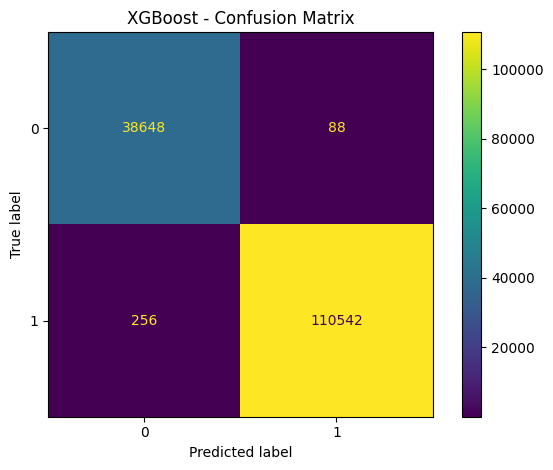

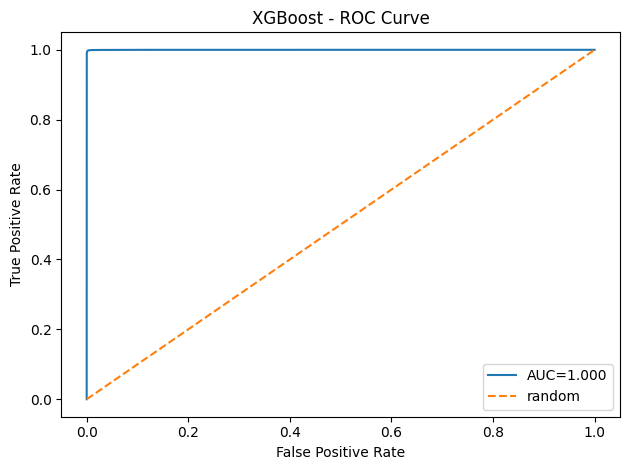

In [25]:
from xgboost import XGBClassifier

# class imbalance 
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_score_xgb = xgb.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_xgb, y_score_xgb, name="XGBoost")
plot_confusion(y_test, y_pred_xgb, title="XGBoost - Confusion Matrix")
plot_roc(y_test, y_score_xgb, title="XGBoost - ROC Curve")

### LightGBM

LightGBM uses histogram-based gradient boosting, making it highly
efficient for large datasets. This efficiency is particularly important
for network security applications.

In [26]:
# !pip install lightgbm

[LightGBM] [Info] Number of positive: 258527, number of negative: 90385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2490
[LightGBM] [Info] Number of data points in the train set: 348912, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

===== LightGBM =====
Accuracy          : 0.9981
Balanced Accuracy : 0.9980
F1-score          : 0.9987
ROC AUC           : 1.0000


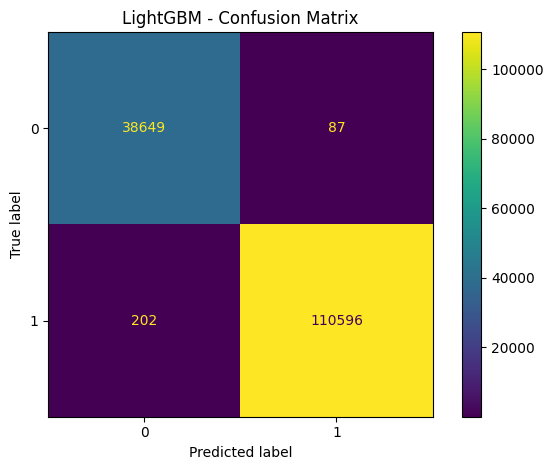

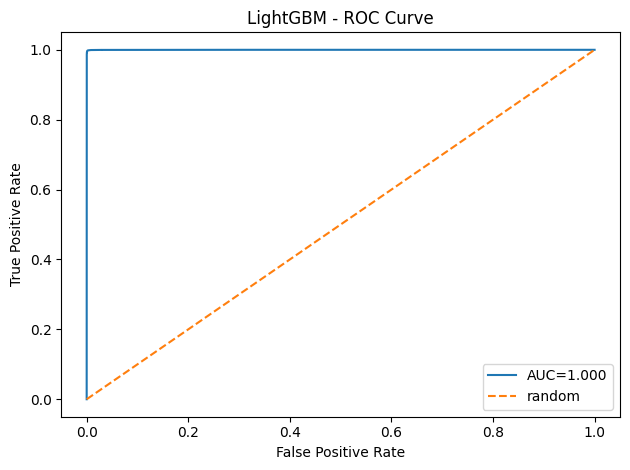

In [27]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    num_leaves=50,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

lgb.fit(X_train, y_train)

y_pred_lgb  = lgb.predict(X_test)
y_score_lgb = lgb.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_lgb, y_score_lgb, name="LightGBM")
plot_confusion(y_test, y_pred_lgb, title="LightGBM - Confusion Matrix")
plot_roc(y_test, y_score_lgb, title="LightGBM - ROC Curve")

## Results Summary

Tree-based models significantly outperform linear baselines.
This demonstrates that flow-level statistical features are highly
informative for malware detection.

## Final Discussion

This project demonstrates that malware traffic can be accurately detected
using only flow-level metadata, without inspecting packet payloads.

Key takeaways:
- Unsupervised anomaly detection captures partial structure but misses many attacks
- Supervised tree-based models achieve near-perfect performance
- Feature engineering grounded in networking domain knowledge is critical

This aligns well with the goals of network machine learning and the
pcapML benchmark.